In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def compute_volume(df):
    # only for monoclinic...
    df['volume'] = df['a'] * df['b'] * df['c'] * np.sin(np.radians(df['beta'])) / 1000. # nm^3
    return

In [3]:
time_humid = pd.read_csv('./time_to_fishing.txt', sep='\s+', comment="#")
compute_volume(time_humid)
time_humid

,dataset,time,a,b,c,alpha,beta,gamma,biomtvol,wilson,rwork,rfree,volume
0,iheat_5999_05,5,114.359,53.579,44.621,90.0,100.909,90.0,81916.757,28.818,0.2408,0.2775,268.462937
1,iheat_5999_07,45,114.385,53.489,44.688,90.0,101.210,90.0,81622.741,34.987,0.3438,0.3942,268.199900
2,iheat_5999_08,65,113.675,53.374,44.707,90.0,102.474,90.0,81881.228,30.305,0.2311,0.2860,264.847208
3,iheat_5999_09,85,112.604,52.830,44.658,90.0,102.901,90.0,81563.854,30.648,0.1671,0.2174,258.958514
4,iheat_5999_10,105,113.074,52.926,44.806,90.0,102.782,90.0,81832.427,31.456,0.1786,0.2186,261.499050
5,iheat_5999_11,125,112.675,52.901,44.820,90.0,102.507,90.0,81807.165,28.243,0.2216,0.2416,260.815290
6,iheat_5999_13,165,110.640,54.049,46.187,90.0,102.372,90.0,0.000,156.646,0.4124,0.4371,269.783295
7,iheat_5999_15,205,108.404,52.752,44.878,90.0,102.634,90.0,0.000,21.631,0.0000,0.0000,250.422198


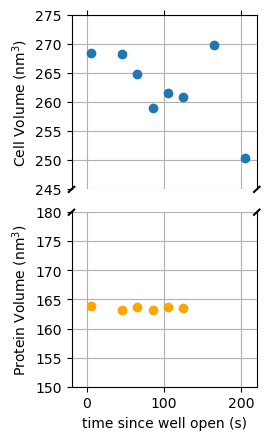

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(2.8, 4.5), sharex=True)
    
axes[0].spines['bottom'].set_visible(False)
axes[1].spines['top'].set_visible(False)
axes[0].xaxis.tick_top()
axes[0].tick_params(labeltop=False)  # don't put tick labels at the top
axes[1].xaxis.tick_bottom()

d = .015  # how big to make the diagonal lines in axes coordinates

kwargs = dict(transform=axes[0].transAxes, color='k', clip_on=False)
axes[0].plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
axes[0].plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=axes[1].transAxes)  # switch to the bottom axes
axes[1].plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
axes[1].plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

p1 = axes[0].plot(time_humid['time'], time_humid['volume'], 'o')
p2 = axes[1].plot(time_humid['time'], (time_humid['biomtvol'] / 1000. * 2.), 'o', color='orange')

# axes[0].set_xlim([-10, 140])
# axes[1].set_xlim([-10, 140])
axes[0].set_ylim([245, 275])
axes[1].set_ylim([150, 180])

axes[0].set_ylabel('Cell Volume (nm$^3$)')
axes[1].set_ylabel('Protein Volume (nm$^3$)')

axes[1].set_xlabel('time since well open (s)')

axes[0].grid()
axes[1].grid()

axes[1].set_xlim([-20, 220])

plt.tight_layout()
plt.savefig('./open_well_series_volumes.pdf')
plt.show()

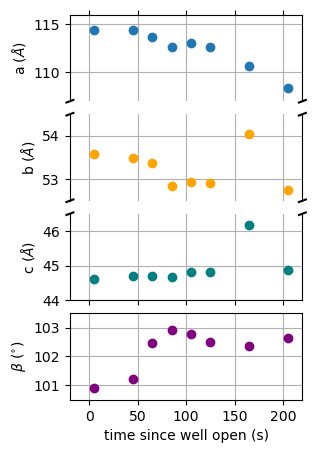

In [82]:
fig, axes = plt.subplots(4, 1, figsize=(3, 5), sharex=True)
plt.subplots_adjust(hspace=0.15)
    
axes[0].spines['bottom'].set_visible(False)
axes[0].xaxis.tick_top()
axes[0].tick_params(labeltop=False)  # don't put tick labels at the top

axes[1].spines['top'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)
axes[1].tick_params(labeltop=False)  # don't put tick labels at the top
axes[1].tick_params(labelbottom=False)  # don't put tick labels at the bottom

for tick in axes[1].xaxis.get_major_ticks():
    tick.tick1On = tick.tick2On = False
    tick.tick1line.set_visible(False)
    tick.tick2line.set_visible(False)
    tick.label1.set_visible(False)
    tick.label2.set_visible(False)

axes[2].spines['top'].set_visible(False)
axes[2].xaxis.tick_bottom()

d = .015  # how big to make the diagonal lines in axes coordinates

kwargs = dict(transform=axes[0].transAxes, color='k', clip_on=False)
axes[0].plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
axes[0].plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=axes[1].transAxes)  # switch to the bottom axes
axes[1].plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
axes[1].plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

kwargs.update(transform=axes[1].transAxes)  # switch to the bottom axes
axes[1].plot((-d, +d), (-d, +d), **kwargs)  # bottom-left diagonal
axes[1].plot((1 - d, 1 + d), (-d, +d), **kwargs)  # bottom-right diagonal

kwargs.update(transform=axes[2].transAxes)  # switch to the bottom axes
axes[2].plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
axes[2].plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

p1 = axes[0].plot(time_humid['time'], time_humid['a'], 'o')
p2 = axes[1].plot(time_humid['time'], time_humid['b'], 'o', color='orange')
p3 = axes[2].plot(time_humid['time'], time_humid['c'], 'o', color='teal')
p4 = axes[3].plot(time_humid['time'], time_humid['beta'], 'o', color='purple')

axes[0].set_ylabel(r'a ($\AA$)')
axes[1].set_ylabel(r'b ($\AA$)')
axes[2].set_ylabel(r'c ($\AA$)')
axes[3].set_ylabel(r'$\beta$ ($^{\circ}$)')

axes[3].set_xlabel('time since well open (s)')

axes[0].grid()
axes[1].grid()
axes[2].grid()
axes[3].grid()

axes[0].set_ylim([107, 116])
axes[1].set_ylim([52.5, 54.5])
axes[2].set_ylim([44, 46.5])
axes[3].set_ylim([100.5, 103.5])

axes[3].set_xlim([-20, 220])

#plt.tight_layout()
plt.savefig('./open_well_series_cell_parameters.pdf', bbox_inches="tight")
plt.show()